# 2023-09-14 VAMPIRES Single-Difference Offset Versus IMR Angle

This notebook measures the HWP-independent vertical center of the normalized single-difference curve at every IMR angle for the selected VAMPIRES filters. FLC A and B are measured separately because they are distinct single-difference curves in this dataset.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display

repo_root = Path('/home/rebeccaz/Github/vampires_calibration')
data_path = repo_root / 'data' / '20230914_processed_table_pyPolCal_version.csv'
filters = ['625-50', '675-50', '725-50', '750-50', '775-50']
flc_states = ['A', 'B']


## Load The Requested Single-Difference Data

In [2]:
required_columns = {
    'FILTER01',
    'OBS-MOD',
    'D_IMRANG',
    'RET-POS1',
    'U_FLC',
    'diff',
    'sum',
}

raw_table = pd.read_csv(data_path)
missing_columns = sorted(required_columns.difference(raw_table.columns))
if missing_columns:
    raise KeyError(f'Missing required CSV columns: {missing_columns}')

single_difference_table = raw_table.loc[
    raw_table['FILTER01'].isin(filters)
    & raw_table['OBS-MOD'].eq('IPOL')
    & raw_table['U_FLC'].isin(flc_states),
    list(required_columns),
].copy()

for column in ('D_IMRANG', 'RET-POS1', 'diff', 'sum'):
    single_difference_table[column] = pd.to_numeric(
        single_difference_table[column], errors='coerce'
    )

finite_mask = np.isfinite(
    single_difference_table[['D_IMRANG', 'RET-POS1', 'diff', 'sum']]
).all(axis=1)
nonzero_sum_mask = single_difference_table['sum'].ne(0.0)
single_difference_table = single_difference_table.loc[
    finite_mask & nonzero_sum_mask
].copy()
single_difference_table['single_difference'] = (
    single_difference_table['diff'] / single_difference_table['sum']
)
single_difference_table = single_difference_table.sort_values(
    ['FILTER01', 'U_FLC', 'D_IMRANG', 'RET-POS1']
).reset_index(drop=True)

measurement_counts = (
    single_difference_table
    .groupby(['FILTER01', 'U_FLC'], sort=False)
    .size()
    .rename('measurements')
    .reset_index()
)
print(f'Loaded {len(single_difference_table)} finite IPOL measurements from {data_path}.')
display(measurement_counts)


Loaded 800 finite IPOL measurements from /home/rebeccaz/Github/vampires_calibration/data/20230914_processed_table_pyPolCal_version.csv.


,FILTER01,U_FLC,measurements
0,625-50,A,80
1,625-50,B,80
2,675-50,A,80
3,675-50,B,80
4,725-50,A,80
5,725-50,B,80
6,750-50,A,80
7,750-50,B,80
8,775-50,A,80
9,775-50,B,80


## Measure Each Vertical Center

For each filter, FLC state, and IMR angle, the constant term is measured together with the fourth-harmonic HWP modulation. The plotted uncertainty comes from the residual covariance of that local least-squares fit.

In [3]:
def measure_single_difference_offsets(table):
    offset_rows = []

    group_columns = ['FILTER01', 'U_FLC', 'D_IMRANG']
    for (filter_name, flc_state, imr_angle_deg), group in table.groupby(
        group_columns, sort=True
    ):
        hwp_angle_deg = group['RET-POS1'].to_numpy(dtype=float)
        measured_difference = group['single_difference'].to_numpy(dtype=float)

        design = np.column_stack(
            (
                np.ones(len(hwp_angle_deg)),
                np.cos(np.deg2rad(4.0 * hwp_angle_deg)),
                np.sin(np.deg2rad(4.0 * hwp_angle_deg)),
            )
        )
        if np.linalg.matrix_rank(design) < design.shape[1]:
            raise ValueError(
                f'Insufficient HWP-angle coverage for {filter_name}, '
                f'FLC {flc_state}, IMR {imr_angle_deg:g} deg.'
            )

        coefficients, _, _, _ = np.linalg.lstsq(
            design, measured_difference, rcond=None
        )
        residuals = measured_difference - design @ coefficients
        degrees_of_freedom = max(len(measured_difference) - design.shape[1], 1)
        residual_variance = float(np.sum(residuals**2) / degrees_of_freedom)
        covariance = residual_variance * np.linalg.pinv(design.T @ design)

        offset_rows.append(
            {
                'filter': filter_name,
                'flc_state': flc_state,
                'imr_angle_deg': float(imr_angle_deg),
                'single_difference_offset': float(coefficients[0]),
                'single_difference_offset_error': float(
                    np.sqrt(max(covariance[0, 0], 0.0))
                ),
                'hwp_measurements': len(measured_difference),
            }
        )

    return (
        pd.DataFrame(offset_rows)
        .sort_values(['filter', 'flc_state', 'imr_angle_deg'])
        .reset_index(drop=True)
    )


imr_offset_table = measure_single_difference_offsets(single_difference_table)
display(imr_offset_table)


,filter,flc_state,imr_angle_deg,single_difference_offset,single_difference_offset_error,hwp_measurements
0,625-50,A,45.0,0.062246,0.012532,8
1,625-50,A,57.5,0.075191,0.012493,8
2,625-50,A,70.0,-0.101521,0.047502,16
3,625-50,A,82.5,-0.010094,0.004993,8
4,625-50,A,95.0,-0.084228,0.003342,8
...,...,...,...,...,...,...
75,775-50,B,82.5,-0.223388,0.028924,8
76,775-50,B,95.0,-0.222964,0.030423,8
77,775-50,B,107.5,-0.205674,0.017710,16
78,775-50,B,120.0,-0.237525,0.021518,8


## Single-Difference Offset Versus IMR Angle

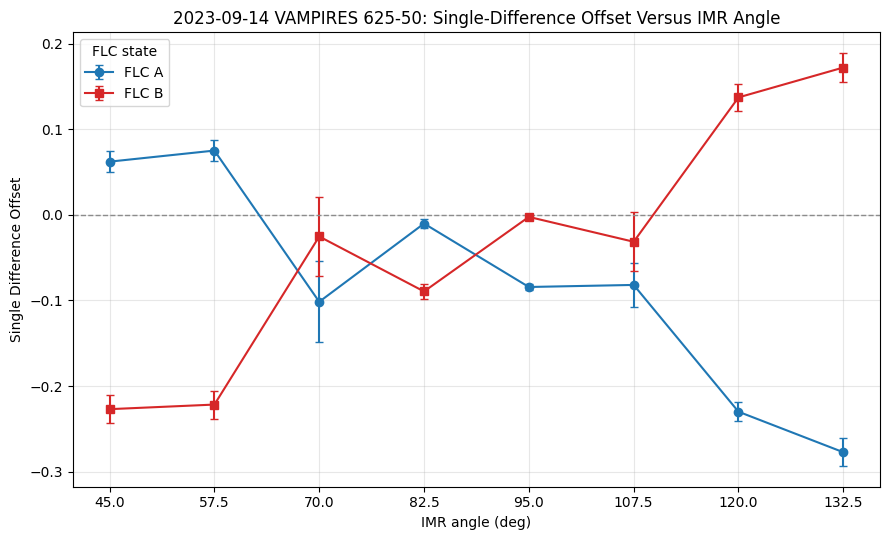

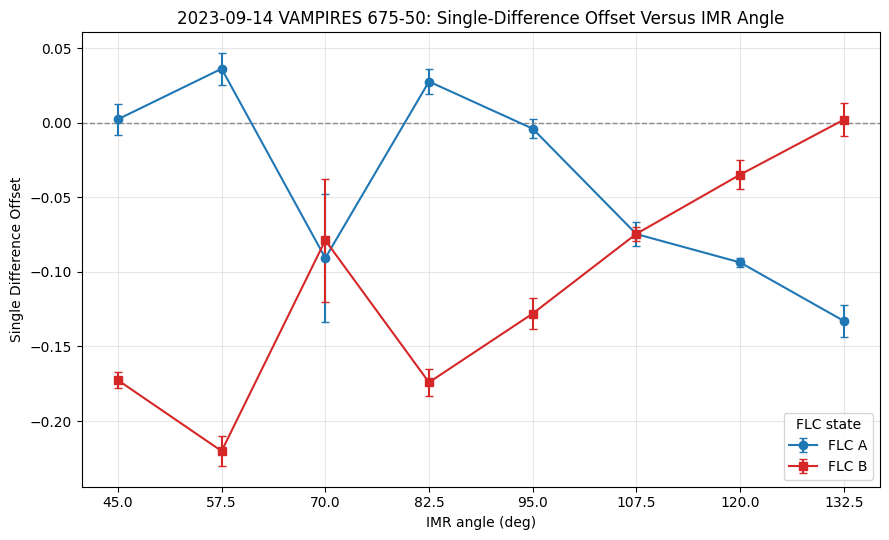

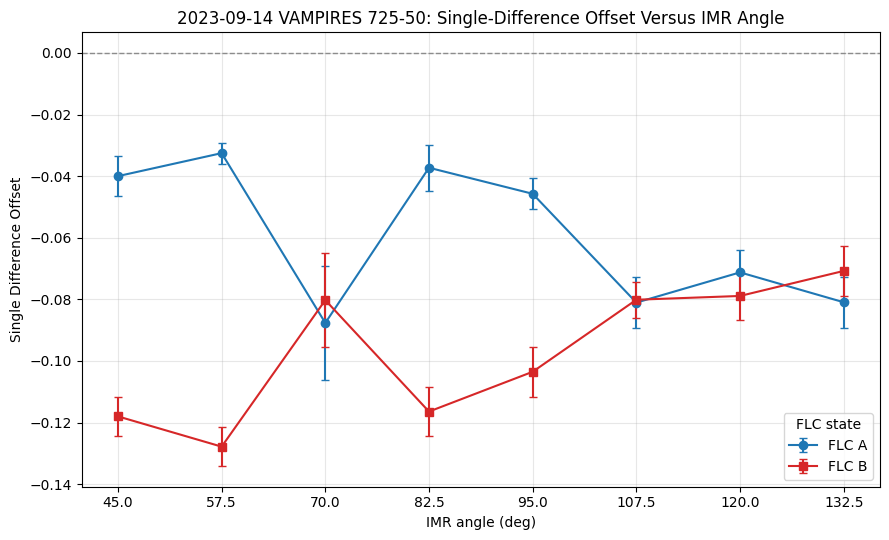

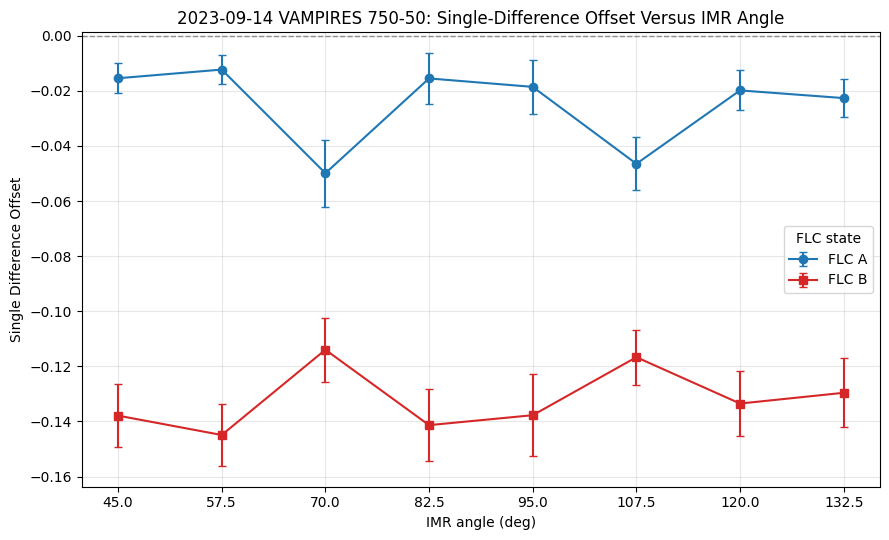

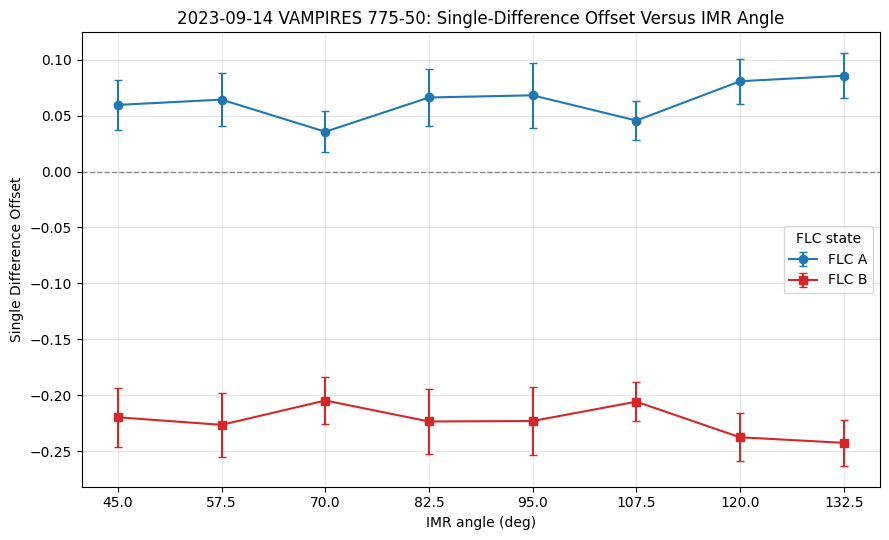

In [4]:
flc_styles = {
    'A': {'color': '#1f77b4', 'marker': 'o'},
    'B': {'color': '#d62728', 'marker': 's'},
}

for filter_name in filters:
    filter_offsets = imr_offset_table.loc[
        imr_offset_table['filter'].eq(filter_name)
    ]
    if filter_offsets.empty:
        print(f'No measurements available for {filter_name}; skipping.')
        continue

    fig, ax = plt.subplots(figsize=(9, 5.5))
    for flc_state in flc_states:
        state_offsets = filter_offsets.loc[
            filter_offsets['flc_state'].eq(flc_state)
        ].sort_values('imr_angle_deg')
        style = flc_styles[flc_state]
        ax.errorbar(
            state_offsets['imr_angle_deg'],
            state_offsets['single_difference_offset'],
            yerr=state_offsets['single_difference_offset_error'],
            fmt=f"{style['marker']}-",
            color=style['color'],
            linewidth=1.5,
            capsize=3,
            label=f'FLC {flc_state}',
        )

    imr_ticks = np.sort(filter_offsets['imr_angle_deg'].unique())
    ax.axhline(0.0, color='0.55', linestyle='--', linewidth=1.0)
    ax.set_xticks(imr_ticks)
    ax.set_xlabel('IMR angle (deg)')
    ax.set_ylabel('Single Difference Offset')
    ax.set_title(
        f'2023-09-14 VAMPIRES {filter_name}: '
        'Single-Difference Offset Versus IMR Angle'
    )
    ax.legend(title='FLC state')
    ax.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()
